# OVIU Hybrid Product Recommendation System

This notebook builds a machine learning based recommendation system for the OVIU e-commerce product purchasing website.

## ML Techniques Used

1. Popularity-based recommendation
2. Market basket / frequently bought together recommendation
3. Content-based filtering using TF-IDF and cosine similarity
4. Item-based collaborative filtering using customer-product interaction matrix
5. Matrix factorization using TruncatedSVD
6. Customer segmentation using K-Means clustering

## Dataset Limitation

The online retail dataset does not include product images. Product images in the website are therefore represented using category-based placeholder visuals.

## 1. Import Libraries

In [1]:
import json
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import coo_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

## 2. Set Project Paths

In [2]:
current_path = Path.cwd()

if (current_path / "data" / "online_retail.csv").exists():
    PROJECT_ROOT = current_path
elif (current_path.parent / "data" / "online_retail.csv").exists():
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path

DATA_PATH = PROJECT_ROOT / "data" / "online_retail.csv"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Models folder:", MODEL_DIR)

Project root: C:\Users\Admin\OVIU-Recommendation-System
Dataset path: C:\Users\Admin\OVIU-Recommendation-System\data\online_retail.csv
Models folder: C:\Users\Admin\OVIU-Recommendation-System\models


## 3. Load and Clean Dataset

In [3]:
def clean_dataset():
    df = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")

    df = df.rename(columns={
        "Invoice": "InvoiceNo",
        "Price": "UnitPrice",
        "Customer ID": "CustomerID"
    })

    required_columns = [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]

    df = df[required_columns]

    df["InvoiceNo"] = df["InvoiceNo"].astype(str)
    df["StockCode"] = df["StockCode"].astype(str)
    df["Description"] = df["Description"].astype(str).str.strip()
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

    df = df[~df["InvoiceNo"].str.startswith("C")]
    df = df.dropna(subset=["Description", "InvoiceDate"])
    df = df[df["Description"].str.lower() != "nan"]
    df = df[df["Description"] != ""]
    df = df[df["Quantity"] > 0]
    df = df[df["UnitPrice"] > 0]

    df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

    return df

df = clean_dataset()

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (1041670, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 4. Dataset Summary

In [ ]:
summary = {
    "Total Rows": len(df),
    "Total Invoices": df["InvoiceNo"].nunique(),
    "Total Products": df["Description"].nunique(),
    "Total Customers": df["CustomerID"].nunique(),
    "Total Countries": df["Country"].nunique(),
    "Total Revenue": round(df["TotalPrice"].sum(), 2)
}

summary

## 5. Exploratory Data Analysis

In [4]:
top_products = (
    df.groupby("Description")
    .agg(
        total_quantity=("Quantity", "sum"),
        total_revenue=("TotalPrice", "sum"),
        orders=("InvoiceNo", "nunique")
    )
    .reset_index()
    .sort_values("total_quantity", ascending=False)
    .head(10)
)

top_products

,Description,total_quantity,total_revenue,orders
5241,WORLD WAR 2 GLIDERS ASSTD DESIGNS,110138,25259.90,1019
5120,WHITE HANGING HEART T-LIGHT HOLDER,96683,266923.55,5455
268,ASSORTED COLOUR BIRD ORNAMENT,81809,132187.92,2807
3148,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
2401,JUMBO BAG RED RETROSPOT,79279,150935.56,3269
2709,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
732,BROCADE RING PURSE,71430,14959.19,456
3084,PACK OF 60 PINK PAISLEY CAKE CASES,56794,28490.98,1993
125,60 TEATIME FAIRY CAKE CASES,54716,27404.22,2127
4571,SMALL POPCORN HOLDER,49948,44090.13,1407


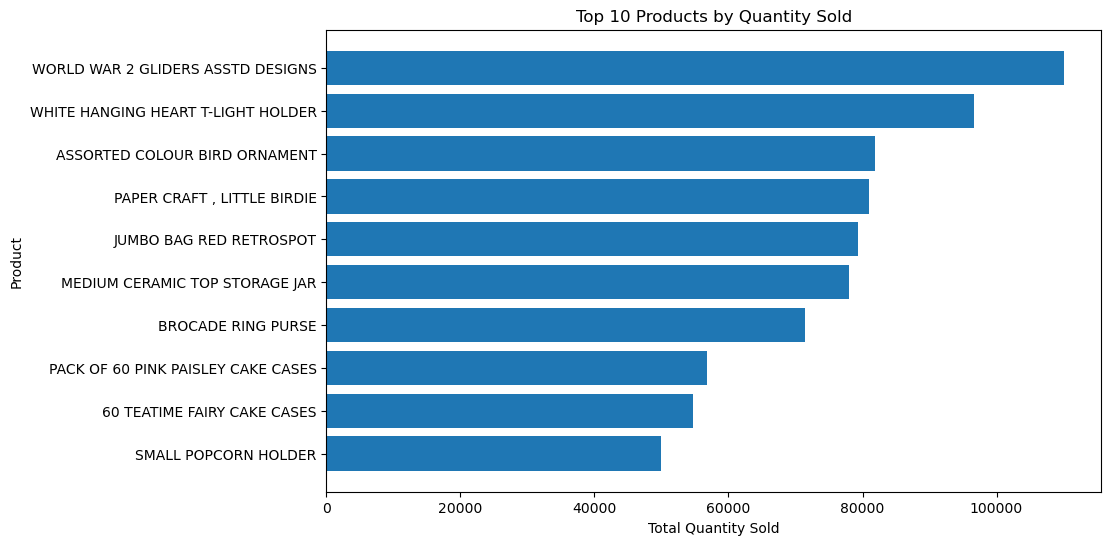

In [5]:
plt.figure(figsize=(10, 6))
plt.barh(top_products["Description"], top_products["total_quantity"])
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.title("Top 10 Products by Quantity Sold")
plt.gca().invert_yaxis()
plt.show()

## 6. Build Product Profile

In [6]:
product_profile = (
    df.groupby("Description")
    .agg(
        stock_code=("StockCode", "first"),
        total_quantity=("Quantity", "sum"),
        total_revenue=("TotalPrice", "sum"),
        average_price=("UnitPrice", "median"),
        orders=("InvoiceNo", "nunique")
    )
    .reset_index()
    .sort_values(["total_quantity", "total_revenue"], ascending=False)
    .head(500)
)

product_profile.head()

,Description,stock_code,total_quantity,total_revenue,average_price,orders
5241,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84077,110138,25259.90,0.29,1019
5120,WHITE HANGING HEART T-LIGHT HOLDER,85123A,96683,266923.55,2.95,5455
268,ASSORTED COLOUR BIRD ORNAMENT,84879,81809,132187.92,1.69,2807
3148,"PAPER CRAFT , LITTLE BIRDIE",23843,80995,168469.60,2.08,1
2401,JUMBO BAG RED RETROSPOT,85099B,79279,150935.56,2.08,3269


## 7. Popularity-Based Recommendation

In [7]:
popular_products = product_profile.head(100).copy()
popular_records = popular_products.to_dict(orient="records")

with open(MODEL_DIR / "popular_products.json", "w", encoding="utf-8") as file:
    json.dump(popular_records, file, indent=2)

popular_products.head(10)

,Description,stock_code,total_quantity,total_revenue,average_price,orders
5241,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84077,110138,25259.90,0.29,1019
5120,WHITE HANGING HEART T-LIGHT HOLDER,85123A,96683,266923.55,2.95,5455
268,ASSORTED COLOUR BIRD ORNAMENT,84879,81809,132187.92,1.69,2807
3148,"PAPER CRAFT , LITTLE BIRDIE",23843,80995,168469.60,2.08,1
2401,JUMBO BAG RED RETROSPOT,85099B,79279,150935.56,2.08,3269
2709,MEDIUM CERAMIC TOP STORAGE JAR,23166,78033,81700.92,1.25,247
732,BROCADE RING PURSE,17003,71430,14959.19,0.29,456
3084,PACK OF 60 PINK PAISLEY CAKE CASES,21977,56794,28490.98,0.55,1993
125,60 TEATIME FAIRY CAKE CASES,84991,54716,27404.22,0.55,2127
4571,SMALL POPCORN HOLDER,22197,49948,44090.13,0.85,1407


## 8. Market Basket / Frequently Bought Together Recommendation

In [8]:
top_product_names = set(product_profile["Description"].head(300).tolist())
basket_df = df[df["Description"].isin(top_product_names)]

baskets = basket_df.groupby("InvoiceNo")["Description"].apply(lambda items: sorted(set(items)))

co_purchase = defaultdict(Counter)

for items in baskets:
    if len(items) < 2:
        continue

    if len(items) > 30:
        items = items[:30]

    for item_a, item_b in combinations(items, 2):
        co_purchase[item_a][item_b] += 1
        co_purchase[item_b][item_a] += 1

market_basket_recommendations = {}

for product, related_items in co_purchase.items():
    market_basket_recommendations[product] = [
        {
            "product": item,
            "score": int(score),
            "method": "Market Basket Analysis"
        }
        for item, score in related_items.most_common(10)
    ]

with open(MODEL_DIR / "market_basket_recommendations.json", "w", encoding="utf-8") as file:
    json.dump(market_basket_recommendations, file, indent=2)

sample_product = list(market_basket_recommendations.keys())[0]
sample_product, market_basket_recommendations[sample_product][:5]

('SAVE THE PLANET MUG',
 [{'product': 'HOME SWEET HOME MUG',
   'score': 210,
   'method': 'Market Basket Analysis'},
  {'product': 'WHITE HANGING HEART T-LIGHT HOLDER',
   'score': 140,
   'method': 'Market Basket Analysis'},
  {'product': 'REGENCY CAKESTAND 3 TIER',
   'score': 94,
   'method': 'Market Basket Analysis'},
  {'product': 'ASSORTED COLOUR BIRD ORNAMENT',
   'score': 90,
   'method': 'Market Basket Analysis'},
  {'product': 'POTTING SHED TEA MUG',
   'score': 89,
   'method': 'Market Basket Analysis'}])

## 9. Content-Based Filtering using TF-IDF + Cosine Similarity

In [9]:
descriptions = product_profile["Description"].astype(str).tolist()

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=3000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(descriptions)
tfidf_similarity_matrix = cosine_similarity(tfidf_matrix)

content_based_recommendations = {}

for index, product_name in enumerate(descriptions):
    similarity_scores = list(enumerate(tfidf_similarity_matrix[index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    related_items = []

    for related_index, score in similarity_scores[1:11]:
        related_product = product_profile.iloc[related_index]

        related_items.append({
            "product": related_product["Description"],
            "stock_code": str(related_product["stock_code"]),
            "score": round(float(score), 4),
            "method": "TF-IDF Content-Based Filtering"
        })

    content_based_recommendations[product_name] = related_items

with open(MODEL_DIR / "content_based_recommendations.json", "w", encoding="utf-8") as file:
    json.dump(content_based_recommendations, file, indent=2)

sample_product = descriptions[0]
sample_product, content_based_recommendations[sample_product][:5]

('WORLD WAR 2 GLIDERS ASSTD DESIGNS',
 [{'product': 'ASSTD DESIGN BUBBLE GUM RING',
   'stock_code': '84270',
   'score': 0.1043,
   'method': 'TF-IDF Content-Based Filtering'},
  {'product': 'WHITE HANGING HEART T-LIGHT HOLDER',
   'stock_code': '85123A',
   'score': 0.0,
   'method': 'TF-IDF Content-Based Filtering'},
  {'product': 'ASSORTED COLOUR BIRD ORNAMENT',
   'stock_code': '84879',
   'score': 0.0,
   'method': 'TF-IDF Content-Based Filtering'},
  {'product': 'PAPER CRAFT , LITTLE BIRDIE',
   'stock_code': '23843',
   'score': 0.0,
   'method': 'TF-IDF Content-Based Filtering'},
  {'product': 'JUMBO BAG RED RETROSPOT',
   'stock_code': '85099B',
   'score': 0.0,
   'method': 'TF-IDF Content-Based Filtering'}])

## 10. Item-Based Collaborative Filtering

In [10]:
top_products_set = set(product_profile["Description"].tolist())

cf_df = df[
    df["CustomerID"].notna()
    & df["Description"].isin(top_products_set)
].copy()

cf_df["CustomerID"] = cf_df["CustomerID"].astype(int).astype(str)

interaction_df = (
    cf_df.groupby(["CustomerID", "Description"])
    .agg(quantity=("Quantity", "sum"))
    .reset_index()
)

customers = sorted(interaction_df["CustomerID"].unique())
products = product_profile["Description"].tolist()

customer_to_index = {customer: index for index, customer in enumerate(customers)}
product_to_index = {product: index for index, product in enumerate(products)}

rows = interaction_df["CustomerID"].map(customer_to_index)
cols = interaction_df["Description"].map(product_to_index)
values = interaction_df["quantity"].astype(float)

user_item_matrix = coo_matrix(
    (values, (rows, cols)),
    shape=(len(customers), len(products))
).tocsr()

item_user_matrix = user_item_matrix.T
collaborative_similarity_matrix = cosine_similarity(item_user_matrix, dense_output=True)

collaborative_recommendations = {}

for index, product_name in enumerate(products):
    similarity_scores = list(enumerate(collaborative_similarity_matrix[index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    related_items = []

    for related_index, score in similarity_scores[1:11]:
        related_product_name = products[related_index]
        related_row = product_profile[product_profile["Description"] == related_product_name].iloc[0]

        related_items.append({
            "product": related_product_name,
            "stock_code": str(related_row["stock_code"]),
            "score": round(float(score), 4),
            "method": "Item-Based Collaborative Filtering"
        })

    collaborative_recommendations[product_name] = related_items

with open(MODEL_DIR / "collaborative_recommendations.json", "w", encoding="utf-8") as file:
    json.dump(collaborative_recommendations, file, indent=2)

print("User-item matrix shape:", user_item_matrix.shape)
sample_product = products[0]
sample_product, collaborative_recommendations[sample_product][:5]

User-item matrix shape: (5710, 500)


('WORLD WAR 2 GLIDERS ASSTD DESIGNS',
 [{'product': 'RED  HARMONICA IN BOX',
   'stock_code': '21915',
   'score': 0.8653,
   'method': 'Item-Based Collaborative Filtering'},
  {'product': 'PACK OF 6 SANDCASTLE FLAGS ASSORTED',
   'stock_code': '21878',
   'score': 0.7864,
   'method': 'Item-Based Collaborative Filtering'},
  {'product': 'BAG 250g SWIRLY MARBLES',
   'stock_code': '21704',
   'score': 0.7863,
   'method': 'Item-Based Collaborative Filtering'},
  {'product': 'RETROSPOT CHILDRENS APRON',
   'stock_code': '21156',
   'score': 0.6973,
   'method': 'Item-Based Collaborative Filtering'},
  {'product': 'PAPER BUNTING RETRO SPOTS',
   'stock_code': '22090',
   'score': 0.6613,
   'method': 'Item-Based Collaborative Filtering'}])

## 11. Matrix Factorization using TruncatedSVD

In [11]:
n_components = 20

if user_item_matrix.shape[1] < n_components:
    n_components = max(2, user_item_matrix.shape[1] - 1)

svd = TruncatedSVD(
    n_components=n_components,
    random_state=42
)

svd.fit(user_item_matrix)

product_factors = svd.components_.T
svd_similarity_matrix = cosine_similarity(product_factors)

matrix_factorization_recommendations = {}

for index, product_name in enumerate(products):
    similarity_scores = list(enumerate(svd_similarity_matrix[index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    related_items = []

    for related_index, score in similarity_scores[1:11]:
        related_product_name = products[related_index]
        related_row = product_profile[product_profile["Description"] == related_product_name].iloc[0]

        related_items.append({
            "product": related_product_name,
            "stock_code": str(related_row["stock_code"]),
            "score": round(float(score), 4),
            "method": "Matrix Factorization with TruncatedSVD"
        })

    matrix_factorization_recommendations[product_name] = related_items

with open(MODEL_DIR / "matrix_factorization_recommendations.json", "w", encoding="utf-8") as file:
    json.dump(matrix_factorization_recommendations, file, indent=2)

sample_product = products[0]
sample_product, matrix_factorization_recommendations[sample_product][:5]

('WORLD WAR 2 GLIDERS ASSTD DESIGNS',
 [{'product': 'BAG 250g SWIRLY MARBLES',
   'stock_code': '21704',
   'score': 0.9442,
   'method': 'Matrix Factorization with TruncatedSVD'},
  {'product': 'PACK OF 6 SANDCASTLE FLAGS ASSORTED',
   'stock_code': '21878',
   'score': 0.9406,
   'method': 'Matrix Factorization with TruncatedSVD'},
  {'product': 'RED  HARMONICA IN BOX',
   'stock_code': '21915',
   'score': 0.9063,
   'method': 'Matrix Factorization with TruncatedSVD'},
  {'product': 'TRADITIONAL WOODEN SKIPPING ROPE',
   'stock_code': '21891',
   'score': 0.8964,
   'method': 'Matrix Factorization with TruncatedSVD'},
  {'product': 'BALLOON WATER BOMB PACK OF 35',
   'stock_code': '22440',
   'score': 0.8835,
   'method': 'Matrix Factorization with TruncatedSVD'}])

## 12. Customer Segmentation using K-Means Clustering

In [12]:
customer_df = df[df["CustomerID"].notna()].copy()
customer_df["CustomerID"] = customer_df["CustomerID"].astype(int).astype(str)

customer_features = (
    customer_df.groupby("CustomerID")
    .agg(
        total_spent=("TotalPrice", "sum"),
        total_quantity=("Quantity", "sum"),
        total_orders=("InvoiceNo", "nunique"),
        unique_products=("Description", "nunique"),
        average_price=("UnitPrice", "mean")
    )
    .reset_index()
)

customer_features["average_order_value"] = (
    customer_features["total_spent"] / customer_features["total_orders"]
)

feature_columns = [
    "total_spent",
    "total_quantity",
    "total_orders",
    "unique_products",
    "average_price",
    "average_order_value"
]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_features[feature_columns])

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_features["cluster"] = kmeans.fit_predict(scaled_features)

cluster_summary = (
    customer_features.groupby("cluster")
    .agg(
        customers=("CustomerID", "count"),
        avg_total_spent=("total_spent", "mean"),
        avg_total_orders=("total_orders", "mean"),
        avg_unique_products=("unique_products", "mean")
    )
    .reset_index()
)

cluster_summary

C:\Users\Admin\miniconda3\envs\adm\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,cluster,customers,avg_total_spent,avg_total_orders,avg_unique_products
0,0,5856,2390.075828,5.838115,81.245902
1,1,19,187042.252105,146.105263,942.105263
2,2,2,12434.920000,1.500000,1.000000
3,3,1,168472.500000,2.000000,3.000000


In [13]:
sorted_clusters = cluster_summary.sort_values(
    "avg_total_spent",
    ascending=False
)["cluster"].tolist()

label_names = [
    "High Value Customers",
    "Frequent Buyers",
    "Regular Customers",
    "Low Activity Customers"
]

cluster_labels = {}

for index, cluster in enumerate(sorted_clusters):
    cluster_labels[int(cluster)] = label_names[index]

customer_segments = {}

for _, row in customer_features.iterrows():
    cluster = int(row["cluster"])

    customer_segments[row["CustomerID"]] = {
        "segment": cluster_labels[cluster],
        "cluster": cluster,
        "total_spent": round(float(row["total_spent"]), 2),
        "total_orders": int(row["total_orders"]),
        "unique_products": int(row["unique_products"])
    }

customer_segment_result = {
    "cluster_labels": cluster_labels,
    "cluster_summary": cluster_summary.to_dict(orient="records"),
    "customer_segments": customer_segments
}

with open(MODEL_DIR / "customer_segments.json", "w", encoding="utf-8") as file:
    json.dump(customer_segment_result, file, indent=2)

list(customer_segments.items())[:5]

[('12346',
  {'segment': 'Low Activity Customers',
   'cluster': 0,
   'total_spent': 77556.46,
   'total_orders': 12,
   'unique_products': 26}),
 ('12347',
  {'segment': 'Low Activity Customers',
   'cluster': 0,
   'total_spent': 5633.32,
   'total_orders': 8,
   'unique_products': 126}),
 ('12348',
  {'segment': 'Low Activity Customers',
   'cluster': 0,
   'total_spent': 2019.4,
   'total_orders': 5,
   'unique_products': 28}),
 ('12349',
  {'segment': 'Low Activity Customers',
   'cluster': 0,
   'total_spent': 4428.69,
   'total_orders': 4,
   'unique_products': 145}),
 ('12350',
  {'segment': 'Low Activity Customers',
   'cluster': 0,
   'total_spent': 334.4,
   'total_orders': 1,
   'unique_products': 17})]

## 13. Build Product Catalog for Website

In [14]:
def detect_category(description):
    text = str(description).lower()

    if "bag" in text:
        return "Bags"
    if "heart" in text:
        return "Decor"
    if "christmas" in text:
        return "Seasonal"
    if "lunch" in text or "box" in text:
        return "Kitchen"
    if "mug" in text or "cup" in text:
        return "Drinkware"
    if "candle" in text or "light" in text:
        return "Home Decor"
    if "card" in text:
        return "Cards"
    if "toy" in text:
        return "Toys"
    if "jewellery" in text or "necklace" in text or "bracelet" in text:
        return "Accessories"

    return "General"


def detect_visual_icon(description):
    text = str(description).lower()

    if "bag" in text:
        return "👜"
    if "heart" in text:
        return "💝"
    if "christmas" in text:
        return "🎄"
    if "lunch" in text or "box" in text:
        return "🍱"
    if "mug" in text or "cup" in text:
        return "☕"
    if "candle" in text or "light" in text:
        return "🕯️"
    if "card" in text:
        return "💌"
    if "toy" in text:
        return "🧸"
    if "jewellery" in text or "necklace" in text or "bracelet" in text:
        return "💎"

    return "🛍️"


catalog_df = (
    df.groupby(["StockCode", "Description"])
    .agg(
        price=("UnitPrice", "median"),
        total_sold=("Quantity", "sum"),
        total_revenue=("TotalPrice", "sum"),
        orders=("InvoiceNo", "nunique")
    )
    .reset_index()
    .sort_values(["total_sold", "total_revenue"], ascending=False)
    .head(300)
)

product_catalog = []

for _, row in catalog_df.iterrows():
    description = str(row["Description"])
    stock_code = str(row["StockCode"])

    product_catalog.append({
        "stock_code": stock_code,
        "name": description.title(),
        "description": description,
        "price": round(float(row["price"]), 2),
        "total_sold": int(row["total_sold"]),
        "total_revenue": round(float(row["total_revenue"]), 2),
        "orders": int(row["orders"]),
        "category": detect_category(description),
        "visual_icon": detect_visual_icon(description)
    })

product_lookup = {
    product["stock_code"]: product
    for product in product_catalog
}

with open(MODEL_DIR / "product_catalog.json", "w", encoding="utf-8") as file:
    json.dump(product_catalog, file, indent=2)

with open(MODEL_DIR / "product_lookup.json", "w", encoding="utf-8") as file:
    json.dump(product_lookup, file, indent=2)

print("Total catalog products:", len(product_catalog))
product_catalog[:3]

Total catalog products: 300


[{'stock_code': '84077',
  'name': 'World War 2 Gliders Asstd Designs',
  'description': 'WORLD WAR 2 GLIDERS ASSTD DESIGNS',
  'price': 0.29,
  'total_sold': 110138,
  'total_revenue': 25259.9,
  'orders': 1019,
  'category': 'General',
  'visual_icon': '🛍️'},
 {'stock_code': '85123A',
  'name': 'White Hanging Heart T-Light Holder',
  'description': 'WHITE HANGING HEART T-LIGHT HOLDER',
  'price': 2.95,
  'total_sold': 96086,
  'total_revenue': 262931.16,
  'orders': 5356,
  'category': 'Decor',
  'visual_icon': '💝'},
 {'stock_code': '84879',
  'name': 'Assorted Colour Bird Ornament',
  'description': 'ASSORTED COLOUR BIRD ORNAMENT',
  'price': 1.69,
  'total_sold': 81809,
  'total_revenue': 132187.92,
  'orders': 2807,
  'category': 'General',
  'visual_icon': '🛍️'}]

## 14. Save ML Model Summary

In [15]:
ml_model_summary = {
    "project": "OVIU Hybrid Product Recommendation System for E-Commerce Purchasing Website",
    "dataset_rows_after_cleaning": int(len(df)),
    "products_used_for_ml": int(len(product_profile)),
    "ml_techniques": [
        "Popularity-Based Recommendation",
        "Market Basket / Frequently Bought Together Recommendation",
        "Content-Based Filtering using TF-IDF and Cosine Similarity",
        "Item-Based Collaborative Filtering using Customer-Product Interaction Matrix",
        "Matrix Factorization using TruncatedSVD",
        "Customer Segmentation using K-Means Clustering"
    ],
    "website_integration": [
        "Home page",
        "Shop page",
        "Product detail page",
        "Cart simulation",
        "Recommendation page",
        "Dashboard analytics"
    ],
    "dataset_limitation": "The dataset does not include product image URLs, so the website uses category-based placeholder visuals."
}

with open(MODEL_DIR / "ml_model_summary.json", "w", encoding="utf-8") as file:
    json.dump(ml_model_summary, file, indent=2)

ml_model_summary

{'project': 'OVIU Hybrid Product Recommendation System for E-Commerce Purchasing Website',
 'dataset_rows_after_cleaning': 1041670,
 'products_used_for_ml': 500,
 'ml_techniques': ['Popularity-Based Recommendation',
  'Market Basket / Frequently Bought Together Recommendation',
  'Content-Based Filtering using TF-IDF and Cosine Similarity',
  'Item-Based Collaborative Filtering using Customer-Product Interaction Matrix',
  'Matrix Factorization using TruncatedSVD',
  'Customer Segmentation using K-Means Clustering'],
 'website_integration': ['Home page',
  'Shop page',
  'Product detail page',
  'Cart simulation',
  'Recommendation page',
  'Dashboard analytics'],
 'dataset_limitation': 'The dataset does not include product image URLs, so the website uses category-based placeholder visuals.'}

## 15. Test Recommendation Output

In [16]:
test_product = product_profile.iloc[0]["Description"]

print("Test Product:", test_product)

print("\nContent-Based Recommendations:")
for item in content_based_recommendations.get(test_product, [])[:5]:
    print("-", item["product"], "| Score:", item["score"])

print("\nCollaborative Filtering Recommendations:")
for item in collaborative_recommendations.get(test_product, [])[:5]:
    print("-", item["product"], "| Score:", item["score"])

print("\nMatrix Factorization Recommendations:")
for item in matrix_factorization_recommendations.get(test_product, [])[:5]:
    print("-", item["product"], "| Score:", item["score"])

Test Product: WORLD WAR 2 GLIDERS ASSTD DESIGNS

Content-Based Recommendations:
- ASSTD DESIGN BUBBLE GUM RING | Score: 0.1043
- WHITE HANGING HEART T-LIGHT HOLDER | Score: 0.0
- ASSORTED COLOUR BIRD ORNAMENT | Score: 0.0
- PAPER CRAFT , LITTLE BIRDIE | Score: 0.0
- JUMBO BAG RED RETROSPOT | Score: 0.0

Collaborative Filtering Recommendations:
- RED  HARMONICA IN BOX | Score: 0.8653
- PACK OF 6 SANDCASTLE FLAGS ASSORTED | Score: 0.7864
- BAG 250g SWIRLY MARBLES | Score: 0.7863
- RETROSPOT CHILDRENS APRON | Score: 0.6973
- PAPER BUNTING RETRO SPOTS | Score: 0.6613

Matrix Factorization Recommendations:
- BAG 250g SWIRLY MARBLES | Score: 0.9442
- PACK OF 6 SANDCASTLE FLAGS ASSORTED | Score: 0.9406
- RED  HARMONICA IN BOX | Score: 0.9063
- TRADITIONAL WOODEN SKIPPING ROPE | Score: 0.8964
- BALLOON WATER BOMB PACK OF 35 | Score: 0.8835
